In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ai4i2020.csv to ai4i2020.csv


In [ ]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df = df.drop(['UDI', 'Product ID'], axis=1)

In [ ]:
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

In [ ]:
X = df.drop([
    'Machine failure',
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF'
], axis=1)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # assume 5% failures
    random_state=42
)

model.fit(X_scaled)

IsolationForest(contamination=0.05, random_state=42)

In [ ]:
df['anomaly'] = model.predict(X_scaled)

In [ ]:
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})

In [ ]:
df['anomaly'].value_counts()

,count
anomaly,
0,9500
1,500


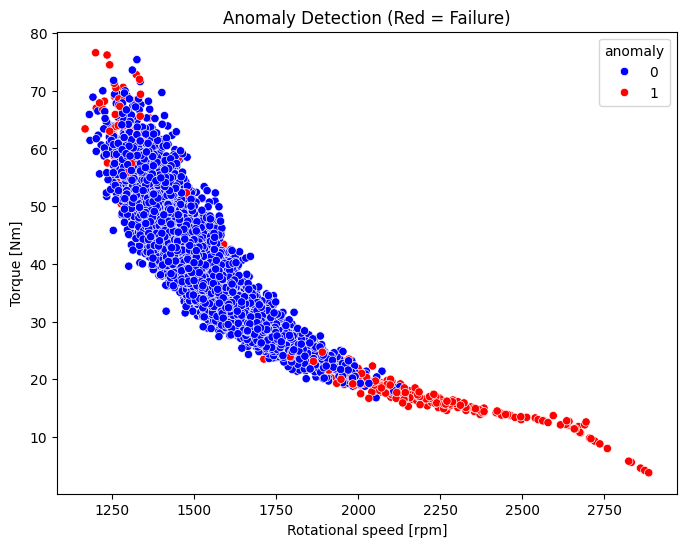

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Rotational speed [rpm]'],
    y=df['Torque [Nm]'],
    hue=df['anomaly'],
    palette=['blue', 'red']
)

plt.title("Anomaly Detection (Red = Failure)")
plt.show()

In [ ]:
pd.crosstab(df['Machine failure'], df['anomaly'])

anomaly,0,1
Machine failure,,
0,9229,432
1,271,68


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("ai4i2020.csv")

# Drop unwanted columns
df = df.drop(['UDI', 'Product ID'], axis=1)

# Encode Type
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

# Save actual labels (ONLY for evaluation)
y_true = df['Machine failure']

# Features only
X = df.drop(['Machine failure','TWF','HDF','PWF','OSF','RNF'], axis=1)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
iso = IsolationForest(contamination=0.05, random_state=42)
iso_pred = iso.fit_predict(X_scaled)

iso_pred = np.where(iso_pred == -1, 1, 0)

In [ ]:
svm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
svm_pred = svm.fit_predict(X_scaled)

svm_pred = np.where(svm_pred == -1, 1, 0)

In [ ]:
db = DBSCAN(eps=1.5, min_samples=10)
db_pred = db.fit_predict(X_scaled)

# DBSCAN: -1 = anomaly
db_pred = np.where(db_pred == -1, 1, 0)

In [ ]:
results = pd.DataFrame({
    'Isolation Forest': iso_pred,
    'One-Class SVM': svm_pred,
    'DBSCAN': db_pred
})

results.sum()

,0
Isolation Forest,500
One-Class SVM,500
DBSCAN,38


In [ ]:
print("Isolation Forest")
print(pd.crosstab(y_true, iso_pred))

print("\nOne-Class SVM")
print(pd.crosstab(y_true, svm_pred))

print("\nDBSCAN")
print(pd.crosstab(y_true, db_pred))

Isolation Forest
col_0               0    1
Machine failure           
0                9229  432
1                 271   68

One-Class SVM
col_0               0    1
Machine failure           
0                9259  402
1                 241   98

DBSCAN
col_0               0   1
Machine failure          
0                9648  13
1                 314  25


In [ ]:
from sklearn.metrics import accuracy_score

print("Isolation Forest:", accuracy_score(y_true, iso_pred))
print("One-Class SVM:", accuracy_score(y_true, svm_pred))
print("DBSCAN:", accuracy_score(y_true, db_pred))

Isolation Forest: 0.9297
One-Class SVM: 0.9357
DBSCAN: 0.9673


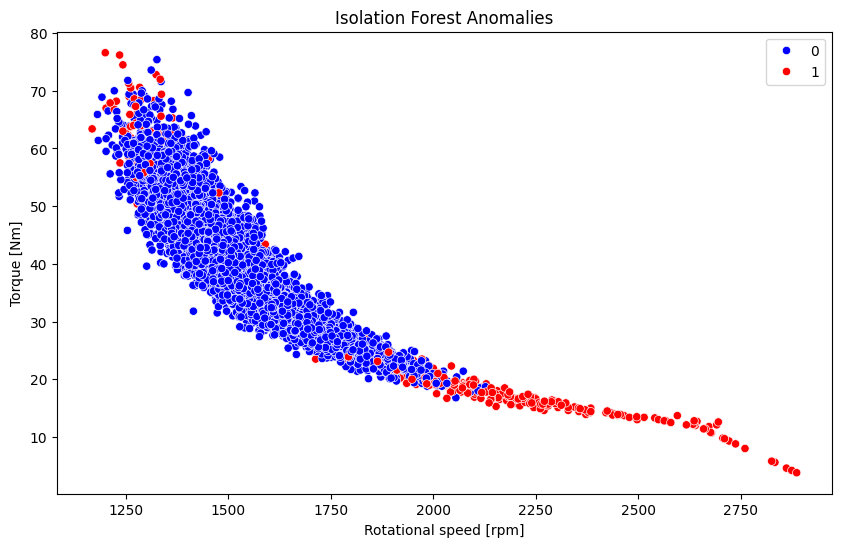

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X['Rotational speed [rpm]'],
    y=X['Torque [Nm]'],
    hue=iso_pred,
    palette=['blue','red']
)

plt.title("Isolation Forest Anomalies")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n🔹 {model_name} Evaluation")

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

In [ ]:
evaluate_model(y_true, iso_pred, "Isolation Forest")
evaluate_model(y_true, svm_pred, "One-Class SVM")
evaluate_model(y_true, db_pred, "DBSCAN")


🔹 Isolation Forest Evaluation
Confusion Matrix:
[[9229  432]
 [ 271   68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      9661
           1       0.14      0.20      0.16       339

    accuracy                           0.93     10000
   macro avg       0.55      0.58      0.56     10000
weighted avg       0.94      0.93      0.94     10000

Accuracy: 0.9297
Precision: 0.136
Recall: 0.20058997050147492
F1 Score: 0.16209773539928488

🔹 One-Class SVM Evaluation
Confusion Matrix:
[[9259  402]
 [ 241   98]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      9661
           1       0.20      0.29      0.23       339

    accuracy                           0.94     10000
   macro avg       0.59      0.62      0.60     10000
weighted avg       0.95      0.94      0.94     10000

Accuracy: 0.9357
Precision: 0.196
Recall: 0.2890855457227

In [ ]:
results = pd.DataFrame({
    "Model": ["Isolation Forest", "One-Class SVM", "DBSCAN"],
    "Accuracy": [
        accuracy_score(y_true, iso_pred),
        accuracy_score(y_true, svm_pred),
        accuracy_score(y_true, db_pred)
    ],
    "Precision": [
        precision_score(y_true, iso_pred),
        precision_score(y_true, svm_pred),
        precision_score(y_true, db_pred)
    ],
    "Recall": [
        recall_score(y_true, iso_pred),
        recall_score(y_true, svm_pred),
        recall_score(y_true, db_pred)
    ],
    "F1 Score": [
        f1_score(y_true, iso_pred),
        f1_score(y_true, svm_pred),
        f1_score(y_true, db_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Isolation Forest,0.9297,0.136000,0.200590,0.162098
1,One-Class SVM,0.9357,0.196000,0.289086,0.233611
2,DBSCAN,0.9673,0.657895,0.073746,0.132626


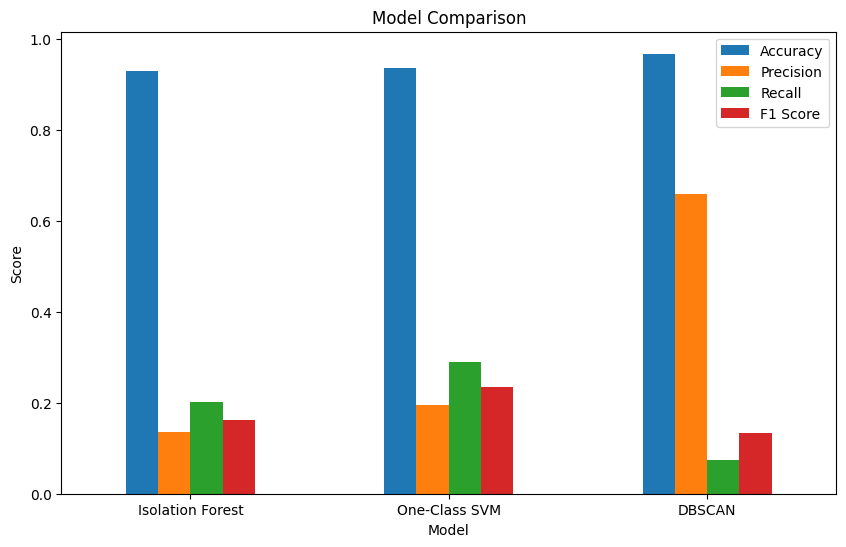

In [ ]:
results.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# New Section